# Clustering Assignment – Theory & Practical (Q1–Q48)



### Q1

**Answer:** Unsupervised learning finds patterns in unlabeled data without known outputs.

### Q2

**Answer:** K-Means initializes centroids, assigns points, updates centroids, and repeats until convergence.

### Q3

**Answer:** A dendrogram is a tree diagram showing hierarchical cluster merging.

### Q4

**Answer:** K-Means needs predefined K; Hierarchical clustering does not.

### Q5

**Answer:** DBSCAN finds arbitrary shaped clusters and detects noise.

### Q6

**Answer:** Silhouette Score evaluates clustering quality without true labels.

### Q7

**Answer:** Hierarchical clustering is computationally expensive for large datasets.

### Q8

**Answer:** K-Means uses distance metrics, which are scale sensitive.

### Q9

**Answer:** DBSCAN marks points not belonging to dense regions as noise.

### Q10

**Answer:** Inertia is the sum of squared distances to cluster centroids.

### Q11

**Answer:** Elbow method helps choose optimal K by observing inertia drop.

### Q12

**Answer:** Density in DBSCAN refers to number of points within eps radius.

### Q13

**Answer:** Yes, but categorical data must be encoded numerically.

### Q14

**Answer:** Negative silhouette score means incorrect clustering.

### Q15

**Answer:** Linkage criteria define distance between clusters.

### Q16

**Answer:** K-Means assumes equal cluster size and density.

### Q17

**Answer:** DBSCAN parameters: eps and min_samples.

### Q18

**Answer:** K-Means++ improves centroid initialization.

### Q19

**Answer:** Agglomerative clustering merges closest clusters iteratively.

### Q20

**Answer:** Silhouette Score considers cohesion and separation, unlike inertia.

## Practical Questions (Q21–Q48)

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import (
    make_blobs, make_moons, make_circles,
    load_iris, load_wine, load_digits, load_breast_cancer
)
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D


### Q21

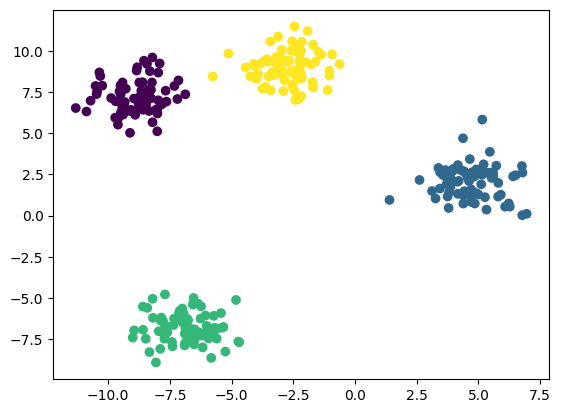

In [2]:

X,_=make_blobs(300,centers=4,random_state=42)
plt.scatter(X[:,0],X[:,1],c=KMeans(4).fit_predict(X))
plt.show()


### Q22

In [3]:

iris=load_iris()
print(AgglomerativeClustering(3).fit_predict(iris.data)[:10])


[1 1 1 1 1 1 1 1 1 1]


### Q23

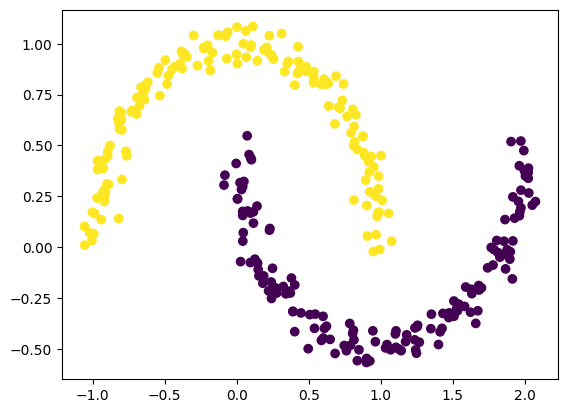

In [4]:

X,_=make_moons(300,noise=0.05)
plt.scatter(X[:,0],X[:,1],c=DBSCAN(0.3).fit_predict(X))
plt.show()


### Q24

In [5]:

X=StandardScaler().fit_transform(load_wine().data)
print(np.bincount(KMeans(3).fit_predict(X)))


[51 63 64]


### Q25

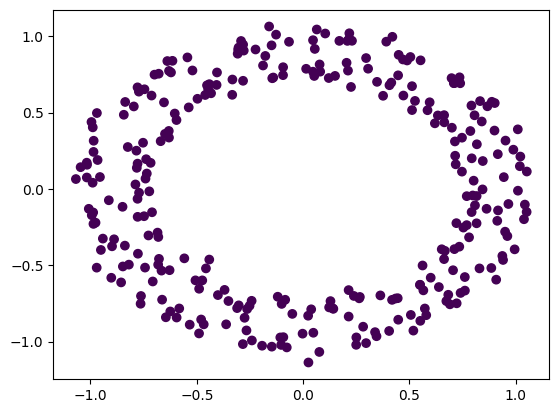

In [6]:

X,_=make_circles(300,noise=0.05)
plt.scatter(X[:,0],X[:,1],c=DBSCAN(0.2).fit_predict(X))
plt.show()


### Q26

In [7]:

X=MinMaxScaler().fit_transform(load_breast_cancer().data)
print(KMeans(2).fit(X).cluster_centers_)


[[0.25535358 0.28833455 0.24696416 0.14388369 0.35743076 0.18019471
  0.10344776 0.1306603  0.34011829 0.25591606 0.06427485 0.18843043
  0.05975663 0.02870108 0.18158628 0.13242941 0.05821528 0.18069336
  0.17221057 0.08403996 0.2052406  0.32069002 0.19242138 0.09943446
  0.3571115  0.14873935 0.13142287 0.26231363 0.22639412 0.15437354]
 [0.50483563 0.39560329 0.50578661 0.36376576 0.46988732 0.42226302
  0.41838662 0.46928035 0.45899738 0.29945886 0.19093085 0.19112073
  0.17903433 0.13086432 0.18017962 0.25890126 0.12542475 0.30942779
  0.190072   0.13266975 0.48047448 0.45107371 0.4655302  0.31460597
  0.49868817 0.36391461 0.39027292 0.65827197 0.33752296 0.26041387]]


### Q27

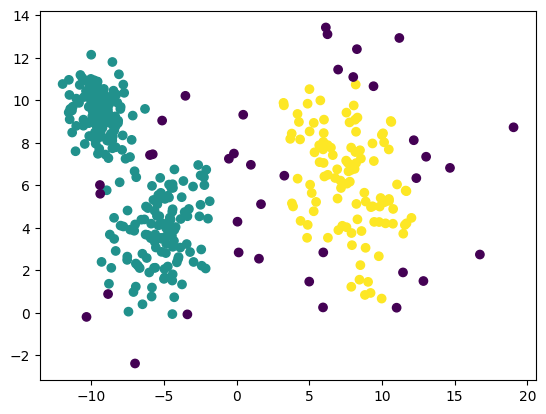

In [8]:

X,_=make_blobs(400,cluster_std=[1,2,3])
plt.scatter(X[:,0],X[:,1],c=DBSCAN(1.2).fit_predict(X))
plt.show()


### Q28

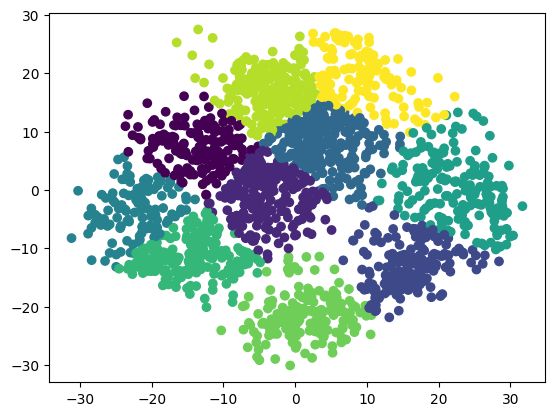

In [9]:

X=PCA(2).fit_transform(load_digits().data)
plt.scatter(X[:,0],X[:,1],c=KMeans(10).fit_predict(X))
plt.show()


### Q29

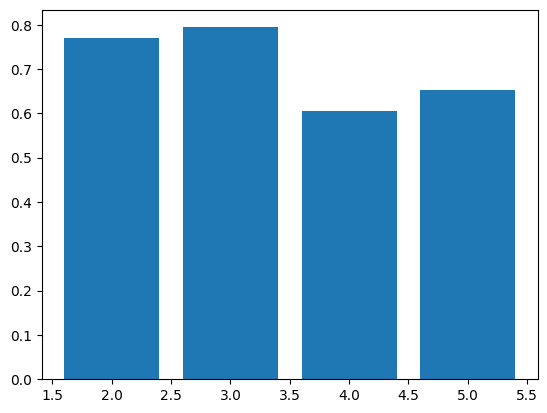

In [10]:

X,_=make_blobs(300)
scores=[silhouette_score(X,KMeans(k).fit_predict(X)) for k in range(2,6)]
plt.bar(range(2,6),scores)
plt.show()


### Q30

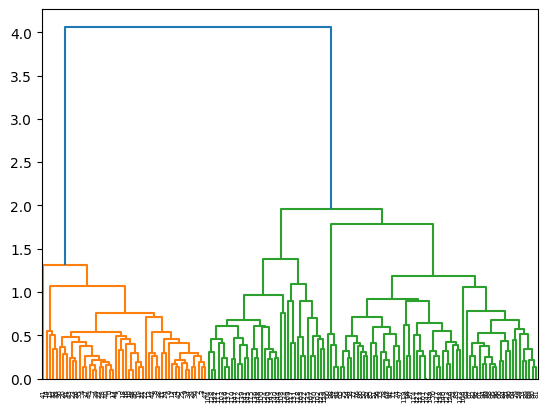

In [11]:

iris=load_iris()
dendrogram(linkage(iris.data,'average'))
plt.show()


### Q31

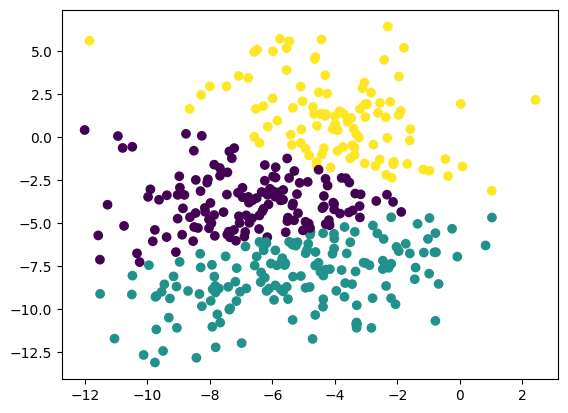

In [12]:

X,_=make_blobs(400,centers=3,cluster_std=2.5)
plt.scatter(X[:,0],X[:,1],c=KMeans(3).fit_predict(X))
plt.show()


### Q32

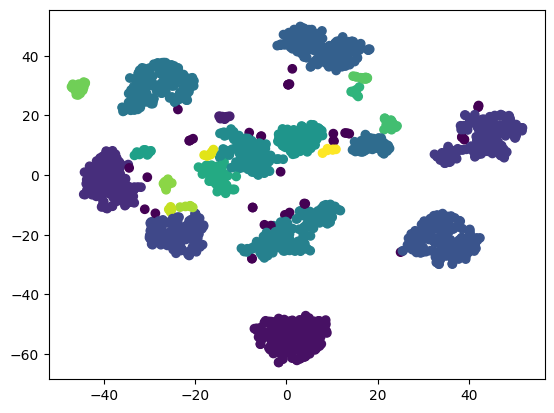

In [13]:

X=TSNE(2).fit_transform(load_digits().data)
plt.scatter(X[:,0],X[:,1],c=DBSCAN(2).fit_predict(X))
plt.show()


### Q33

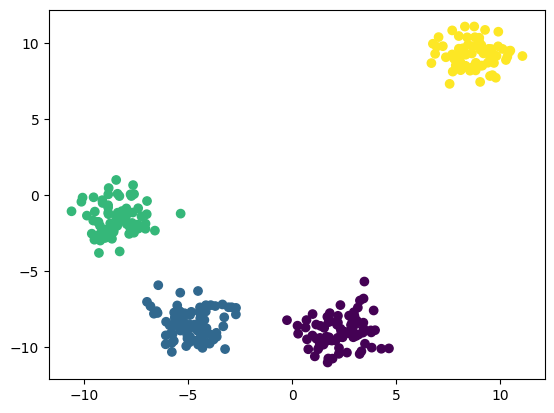

In [14]:

X,_=make_blobs(300,centers=4)
plt.scatter(X[:,0],X[:,1],c=AgglomerativeClustering(4,linkage='complete').fit_predict(X))
plt.show()


### Q34

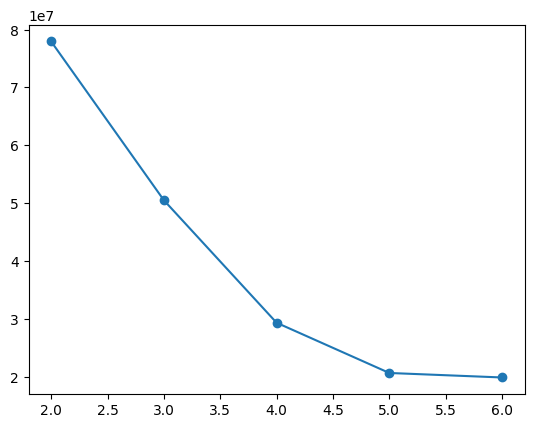

In [15]:

X=load_breast_cancer().data
inertia=[KMeans(k).fit(X).inertia_ for k in range(2,7)]
plt.plot(range(2,7),inertia,marker='o')
plt.show()


### Q35

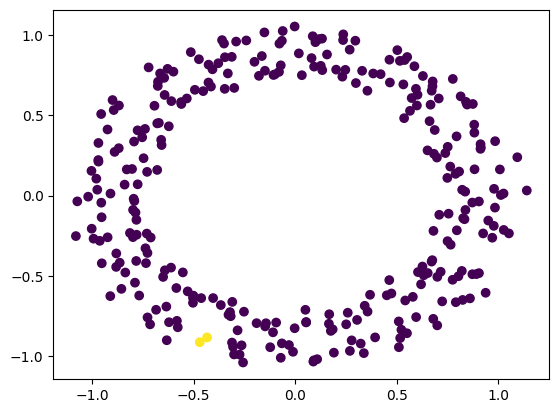

In [16]:

X,_=make_circles(300,noise=0.05)
plt.scatter(X[:,0],X[:,1],c=AgglomerativeClustering(2,linkage='single').fit_predict(X))
plt.show()


### Q36

In [17]:

X=StandardScaler().fit_transform(load_wine().data)
labels=DBSCAN(1.2).fit_predict(X)
print(len(set(labels))-(1 if -1 in labels else 0))


0


### Q37

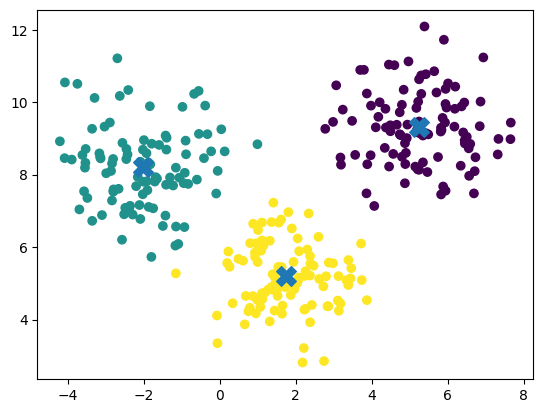

In [18]:

X,_=make_blobs(300,centers=3)
k=KMeans(3).fit(X)
plt.scatter(X[:,0],X[:,1],c=k.labels_)
plt.scatter(k.cluster_centers_[:,0],k.cluster_centers_[:,1],s=200,marker='X')
plt.show()


### Q38

In [19]:

iris=load_iris()
labels=DBSCAN(0.6).fit_predict(StandardScaler().fit_transform(iris.data))
print(labels.tolist().count(-1))


26


### Q39

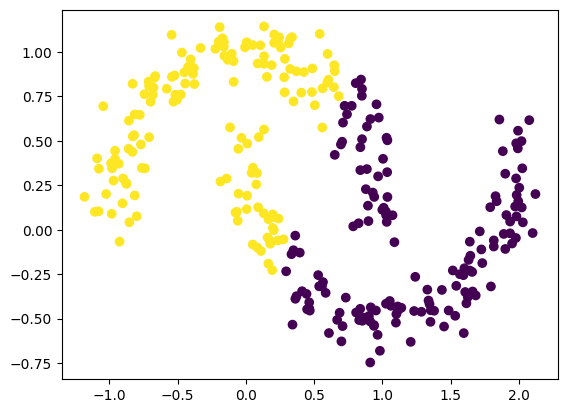

In [20]:

X,_=make_moons(300,noise=0.1)
plt.scatter(X[:,0],X[:,1],c=KMeans(2).fit_predict(X))
plt.show()


### Q40

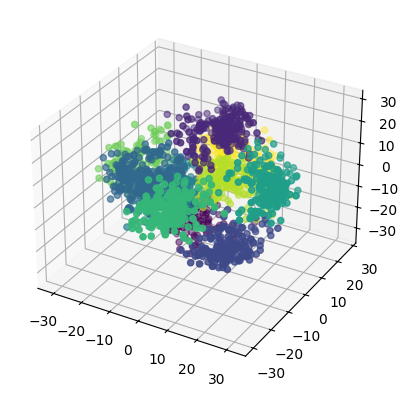

In [21]:

X=PCA(3).fit_transform(load_digits().data)
labels=KMeans(10).fit_predict(X)
fig=plt.figure()
ax=fig.add_subplot(111,projection='3d')
ax.scatter(X[:,0],X[:,1],X[:,2],c=labels)
plt.show()


### Q41

In [22]:

X,_=make_blobs(300,centers=5)
print(silhouette_score(X,KMeans(5).fit_predict(X)))


0.5623401064706656


### Q42

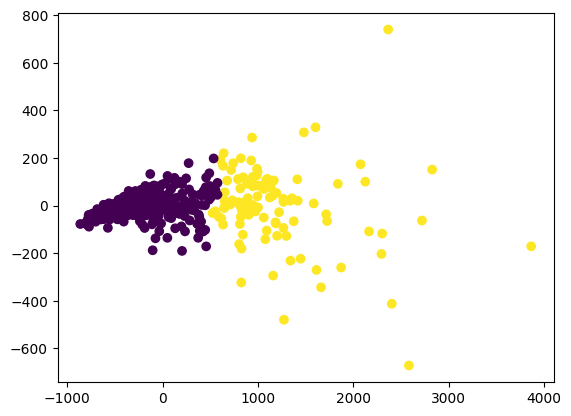

In [23]:

X=PCA(2).fit_transform(load_breast_cancer().data)
plt.scatter(X[:,0],X[:,1],c=AgglomerativeClustering(2).fit_predict(X))
plt.show()


### Q43

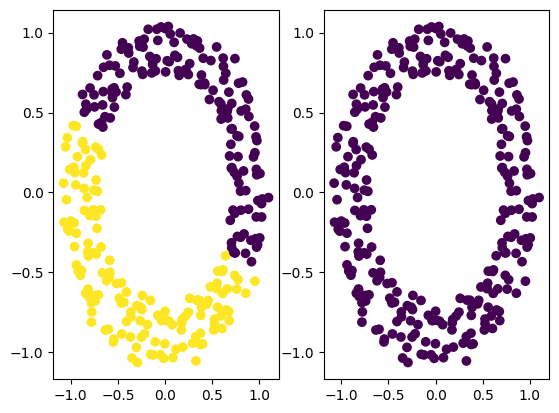

In [24]:

X,_=make_circles(300,noise=0.05)
plt.subplot(1,2,1)
plt.scatter(X[:,0],X[:,1],c=KMeans(2).fit_predict(X))
plt.subplot(1,2,2)
plt.scatter(X[:,0],X[:,1],c=DBSCAN(0.2).fit_predict(X))
plt.show()


### Q44

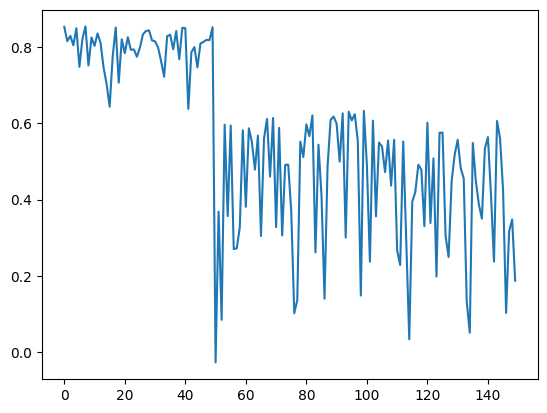

In [25]:

iris=load_iris()
vals=silhouette_samples(iris.data,KMeans(3).fit_predict(iris.data))
plt.plot(vals)
plt.show()


### Q45

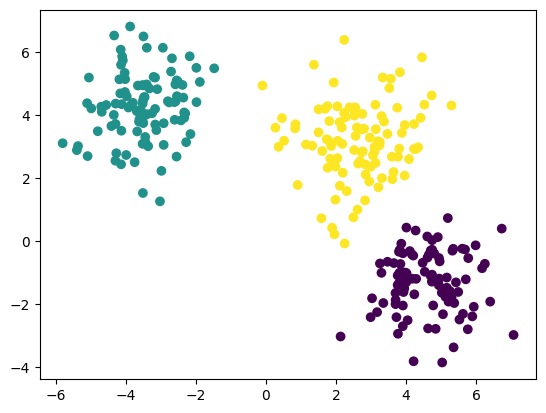

In [26]:

X,_=make_blobs(300,centers=3)
plt.scatter(X[:,0],X[:,1],c=AgglomerativeClustering(3,linkage='average').fit_predict(X))
plt.show()


### Q46

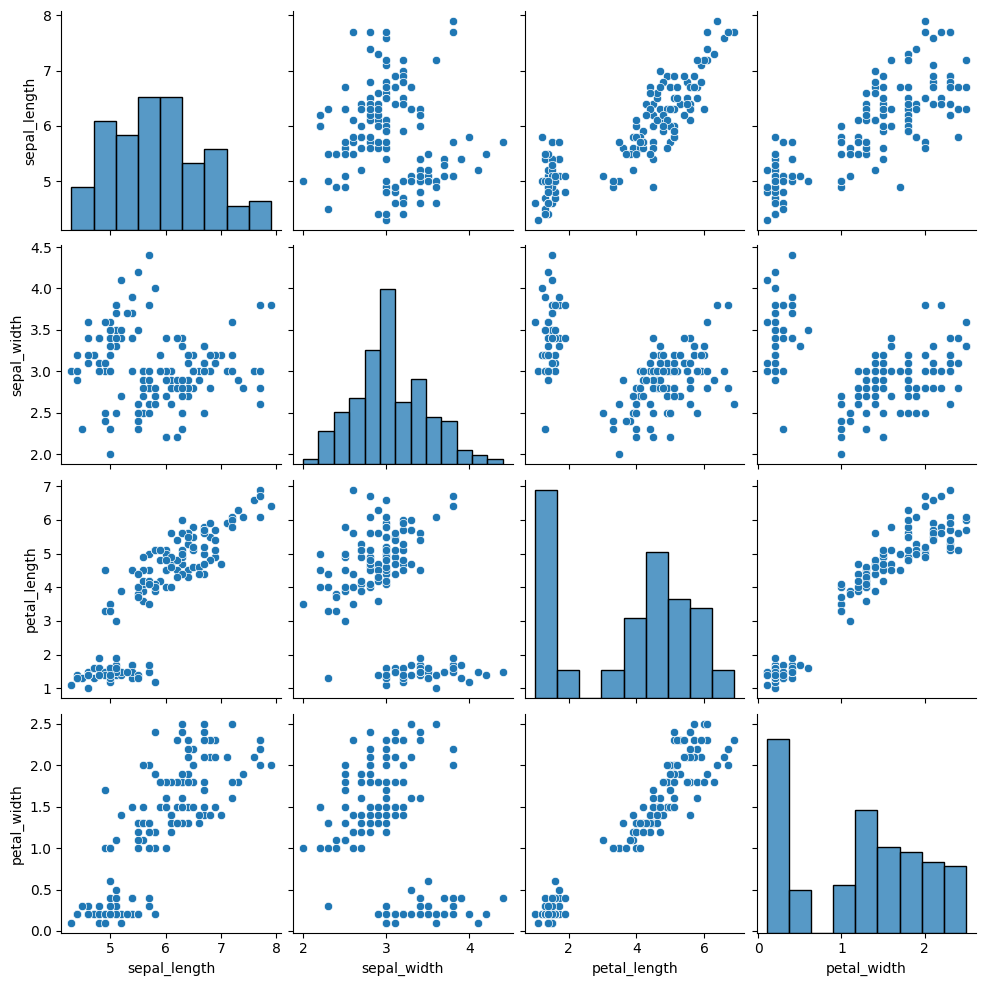

In [27]:

sns.pairplot(sns.load_dataset('iris'))
plt.show()


### Q47

In [32]:
# Q47: Noisy blobs + DBSCAN (FIXED)
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN

X, _ = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)
labels = DBSCAN(eps=0.9, min_samples=5).fit_predict(X)

print("Noise points:", list(labels).count(-1))


Noise points: 8


### Q48

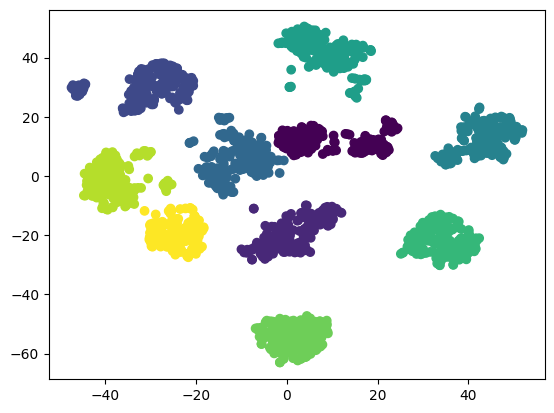

In [29]:

X=TSNE(2).fit_transform(load_digits().data)
plt.scatter(X[:,0],X[:,1],c=AgglomerativeClustering(10).fit_predict(X))
plt.show()
